In [1]:
import numpy as np
import gudhi as gd
import pandas as pd
from sklearn import manifold
from pylab import *
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.tri as mtri
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

In [20]:
stations = np.loadtxt('data/points/CTA_L_X_Y.txt', delimiter=",", skiprows=1)

#fake stations
num_points_edge = 9

lon_min, lon_max =  -87.825, -87.675
lat_min, lat_max =  41.70, 42.10

bottom = np.column_stack((np.linspace(lon_min, lon_max, num_points_edge),np.full(num_points_edge, lat_min)))

top = np.column_stack((np.linspace(lon_min, lon_max, num_points_edge),np.full(num_points_edge, lat_max)))


left = np.column_stack((np.full(num_points_edge, lon_min),np.linspace(lat_min, lat_max, num_points_edge)))


fake_stations = np.vstack([bottom, top, left])

all_stations = np.vstack([stations, fake_stations])

<Axes: title={'center': 'Persistence density'}, xlabel='Birth', ylabel='Death'>

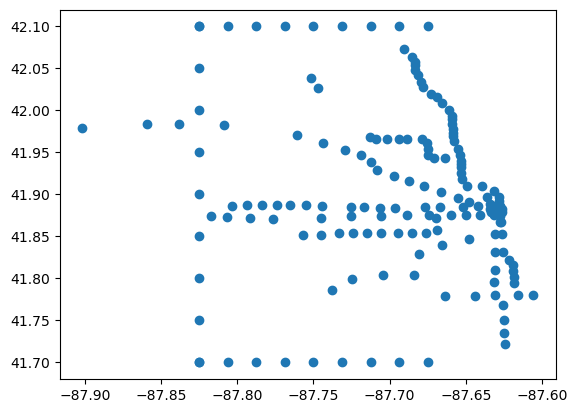

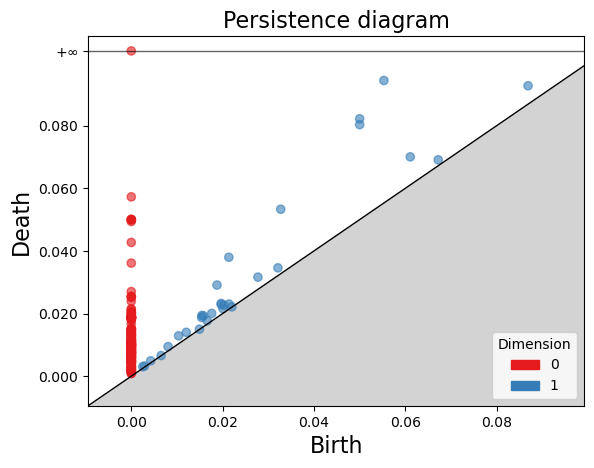

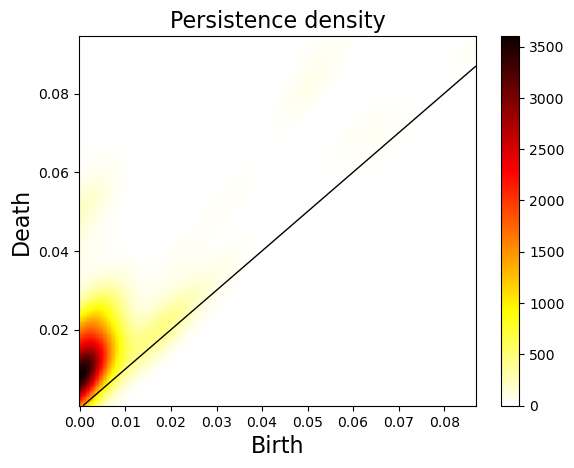

In [21]:
sta_rips_complex = gd.RipsComplex(points=all_stations)
sta_tree = sta_rips_complex.create_simplex_tree(max_dimension=2)

barcodes_sta=sta_tree.persistence()

sta_tree.compute_persistence()
plt.scatter(all_stations[:,0], all_stations[:,1])
gd.plot_persistence_diagram(barcodes_sta)
gd.plot_persistence_density(barcodes_sta)

[[0.05531322 0.09443064]
 [0.05       0.08218966]
 [0.05       0.08033028]
 [0.03272453 0.0533043 ]
 [0.02135608 0.0379751 ]
 [0.01876452 0.02909447]
 [0.06107945 0.0700299 ]
 [0.0868728  0.09274138]
 [0.01545986 0.01936717]
 [0.02773173 0.03162133]
 [0.01968407 0.02321985]
 [0.01577982 0.01928029]
 [0.01542078 0.01874116]
 [0.01967985 0.02287641]
 [0.01036312 0.01287365]
 [0.03210455 0.03459167]
 [0.01761006 0.02004032]
 [0.02030238 0.02261259]
 [0.01204269 0.01399065]
 [0.06719893 0.06909459]
 [0.02138199 0.02302822]
 [0.02007392 0.02153812]
 [0.00805179 0.0094294 ]
 [0.01661903 0.01766598]
 [0.00424967 0.00489891]
 [0.00252228 0.00302018]
 [0.00289844 0.00325175]
 [0.02201773 0.02212049]
 [0.01492056 0.01499537]
 [0.00653474 0.00658412]]


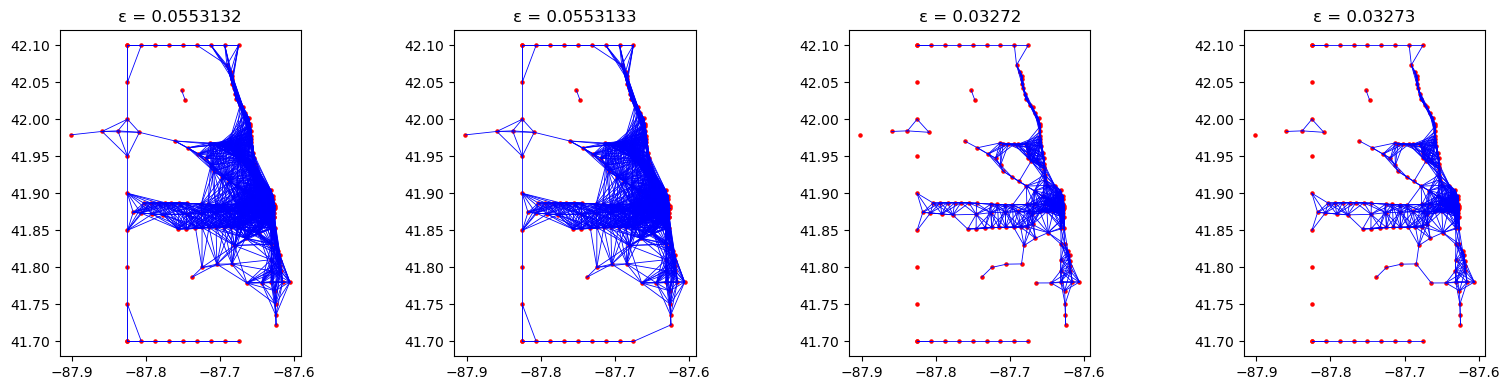

In [23]:
Ista1 = sta_tree.persistence_intervals_in_dimension(1)
lifetimes1 = Ista1[:,1] - Ista1[:,0]
order = np.argsort(lifetimes1)[::-1]
Ista_sorted1 = Ista1[order]
print(Ista_sorted1)

I0sta = sta_tree.persistence_intervals_in_dimension(0)
lifetimes0 = I0sta[:,1]
order = np.argsort(lifetimes0)[::-1]
Ista_sorted0 = I0sta[order]
#print(Ista_sorted0)

epsilons = [0.0553132, 0.0553133, 0.03272, 0.03273]

fig, axes = plt.subplots(1, 4, figsize=(16,4))

for ax, epsilon in zip(axes, epsilons):

    edges = []
    triangles = []

    for simplex, filt in sta_tree.get_skeleton(2):
        if filt <= epsilon:
            if len(simplex) == 2:
                edges.append(simplex)

    edges = np.array(edges)

    for e in edges:
        x = all_stations[e,0]
        y = all_stations[e,1]
        ax.plot(x, y, color='blue', lw=0.6)

    ax.scatter(all_stations[:,0], all_stations[:,1], color='red', s=5)
    ax.set_aspect('equal')
    ax.set_title(f"ε = {epsilon}")

plt.tight_layout()
plt.show()